# MNIST using PyTorch

This notebook builds a small fully connected neural network with PyTorch, trains it on MNIST, and checks its accuracy.

In [1]:
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader
from datasets import load_dataset
from torchvision.transforms import ToTensor

print(f"PyTorch version: {torch.__version__}")

/Users/npoudel/Documents/coding/mnist-from-scratch/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.13.0


In [2]:
# Prefer Apple's Metal backend on this Mac, then CUDA, then the CPU.
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

# Make runs more reproducible.
torch.manual_seed(0)

Using device: mps


## Load and inspect MNIST

`ToTensor` converts each 28×28 image to a tensor with values in `[0, 1]`. Normalization is intentionally omitted here so the preprocessing stays easy to inspect.

Training examples: 60,000
Test examples: 10,000
Batch shape: torch.Size([64, 1, 28, 28])


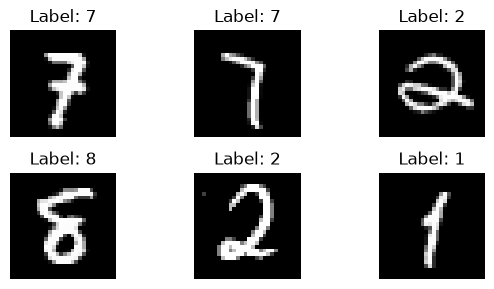

In [ ]:
dataset = load_dataset("ylecun/mnist")
transform = ToTensor()


def transform_batch(batch):
    batch["image"] = [transform(image) for image in batch["image"]]
    return batch


# with_transform applies ToTensor when examples are retrieved.
train_dataset = dataset["train"].with_transform(transform_batch)
test_dataset = dataset["test"].with_transform(transform_batch)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

batch = next(iter(train_loader))
images, labels = batch["image"], batch["label"]
print(f"Training examples: {len(train_dataset):,}")
print(f"Test examples: {len(test_dataset):,}")
print(f"Batch shape: {images.shape}")

plt.figure(figsize=(6, 3))
for index in range(6):
    plt.subplot(2, 3, index + 1)
    plt.imshow(images[index].squeeze(), cmap="gray")s
    plt.title(f"Label: {labels[index].item()}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## Define the model

Each image is flattened from 28×28 pixels into 784 inputs. The model uses one hidden layer and produces one score for each of the 10 digits.

In [9]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Linear(128, 10),
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=10, bias=True)
)


## Train and evaluate

The training loop moves each batch to the selected device, computes the loss, backpropagates gradients, and updates the model parameters.

In [10]:
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()
    total_loss = 0.0

    for batch in loader:
        images, labels = batch["image"].to(device), batch["label"].to(device)

        optimizer.zero_grad()
        predictions = model(images)
        loss = loss_fn(predictions, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    correct = 0

    for batch in loader:
        images, labels = batch["image"].to(device), batch["label"].to(device)
        predictions = model(images)
        total_loss += loss_fn(predictions, labels).item() * images.size(0)
        correct += (predictions.argmax(dim=1) == labels).sum().item()

    average_loss = total_loss / len(loader.dataset)
    accuracy = correct / len(loader.dataset)
    return average_loss, accuracy


num_epochs = 3
for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
    test_loss, test_accuracy = evaluate(model, test_loader, loss_fn, device)
    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"train loss: {train_loss:.4f} | "
        f"test loss: {test_loss:.4f} | "
        f"test accuracy: {test_accuracy:.2%}"
    )

Epoch 1/3 | train loss: 0.3396 | test loss: 0.1781 | test accuracy: 94.79%
Epoch 2/3 | train loss: 0.1520 | test loss: 0.1214 | test accuracy: 96.44%
Epoch 3/3 | train loss: 0.1071 | test loss: 0.1003 | test accuracy: 96.95%


## Inspect predictions

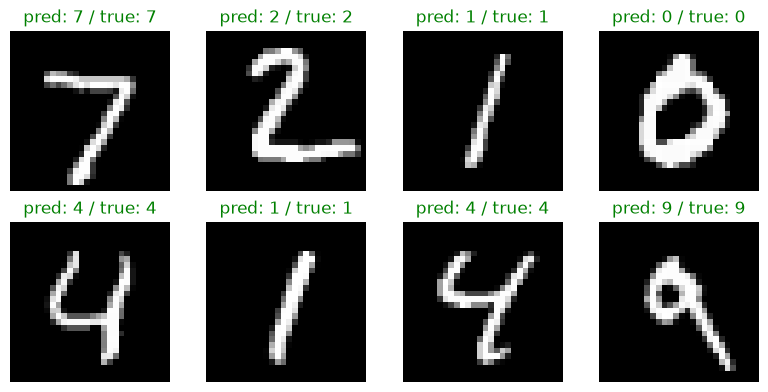

In [11]:
model.eval()
batch = next(iter(test_loader))
images, labels = batch["image"], batch["label"]
with torch.no_grad():
    predictions = model(images.to(device)).argmax(dim=1).cpu()

plt.figure(figsize=(8, 4))
for index in range(8):
    plt.subplot(2, 4, index + 1)
    plt.imshow(images[index].squeeze(), cmap="gray")
    color = "green" if predictions[index] == labels[index] else "red"
    plt.title(f"pred: {predictions[index].item()} / true: {labels[index].item()}", color=color)
    plt.axis("off")
plt.tight_layout()
plt.show()